# 03-Local Surrogate Perturbation (LIME)

In Lesson 02, we implemented SHAP to extract exact cooperative game-theoretic attributions. While TreeSHAP is incredibly fast for ensemble models, calculating exact Shapley values for deep neural networks or massive text/image models using KernelSHAP is computationally catastrophic (scaling exponentially as $\mathcal{O}(2^M)$).

If an API request takes 50 milliseconds to execute a prediction, we cannot wait 30 seconds to compute its explanation. We need a fast, completely **Model-Agnostic** framework.

Enter **LIME (Local Interpretable Model-agnostic Explanations)**. LIME abandons the attempt to explain the entire global model. Instead, it mathematically asserts that even if a neural network's decision boundary is insanely complex globally, it is almost always **linear locally**. LIME dynamically generates a microscopic, heavily weighted dataset around the specific prediction, queries the black box, and trains a transparent Glassbox model (like Ridge Regression) exclusively on that localized geometry.

## 1. The Mathematics of Local Surrogate Perturbation

### The LIME Objective Function

We want to explain a specific prediction $x$ made by a black-box model $f(x)$. We introduce a family of interpretable models $G$ (e.g., linear regressions, decision stumps). Our goal is to find the optimal surrogate model $g \in G$ that minimizes the loss $\mathcal{L}$ in the local neighborhood, while strictly bounding the complexity of the explanation $\Omega(g)$.

The mathematical optimization is defined as:


$$\xi(x) = \arg\min_{g \in G} \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

* $f(z)$: The prediction of the black box on a perturbed sample $z$.
* $g(z)$: The prediction of the interpretable surrogate on $z$.
* $\pi_x(z)$: The **Proximity Kernel**, defining how close the perturbed sample $z$ is to the original instance $x$.

### The Proximity Kernel ($\pi_x$) and Perturbation

LIME does not use the original training data to build the explanation. It creates a brand new synthetic dataset on the fly.
For tabular data, it draws samples $z$ from a normal distribution based on the training set's mean and variance. It then weights every sample using an exponential distance kernel (typically based on $L_2$ Euclidean distance or Cosine similarity) with a bandwidth parameter $\sigma$:


$$\pi_x(z) = \exp \left( \frac{-D(x, z)^2}{\sigma^2} \right)$$


If a perturbed sample $z$ is far away from $x$, its weight approaches $0.0$, and the surrogate model ignores it. If $z$ is extremely close to $x$, its weight approaches $1.0$, forcing the surrogate model to perfectly mimic the black box at that exact coordinate.

### Weighted Least Squares

With the perturbed dataset $Z$, the black-box predictions $f(Z)$, and the proximity weights $\pi_x(Z)$, LIME solves a Weighted Least Squares regression to calculate the final interpretable coefficients $\beta$:


$$\hat{\beta} = \arg\min_{\beta} \sum_{z \in Z} \pi_x(z) \left( f(z) - \beta^T z \right)^2$$

## 2. Imperative Execution: The Local Perturbation Engine

Let's build a local Python environment, train an unconstrained Random Forest (Black Box), and instantiate the `LimeTabularExplainer` to generate synthetic perturbations and fit the local linear surrogate.

In [2]:
# Required installations: pip install lime scikit-learn pandas numpy
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from lime.lime_tabular import LimeTabularExplainer

print("--- 🚀 Initializing LIME Perturbation Sandbox ---")

# 1. 📝 Load dataset and train a Black-Box Model
data = load_breast_cancer()
feature_names = data.feature_names
X = pd.DataFrame(data.data, columns=feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a highly non-linear Random Forest (100 trees, unconstrained depth)
black_box_model = RandomForestClassifier(n_estimators=100, random_state=42)
black_box_model.fit(X_train, y_train)

# 2. ⚡ Instantiate the Explainer
# LIME requires the training data to calculate the mean/variance for generating perturbations
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    mode='classification',
    discretize_continuous=True, # Bins continuous features for clearer human explanations
    random_state=42
)

# 3. 🧮 Execute Local Surrogate Training on a Single Instance
instance_idx = 14
sample_instance = X_test.iloc[instance_idx]

print("\n--- 🧮 Generating 5,000 Perturbed Samples & Fitting Surrogate ---")
# LIME dynamically generates 5,000 synthetic neighbors, queries the Random Forest, 
# and fits a Ridge Regression model weighted by the exponential proximity kernel.
explanation = explainer.explain_instance(
    data_row=sample_instance.values,
    predict_fn=black_box_model.predict_proba,
    num_features=6,     # Limit explanation complexity to the top 6 driving features
    num_samples=5000    # Number of synthetic perturbations z
)

print("   ✅ Local surrogate model successfully converged.")

--- 🚀 Initializing LIME Perturbation Sandbox ---

--- 🧮 Generating 5,000 Perturbed Samples & Fitting Surrogate ---


/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


   ✅ Local surrogate model successfully converged.


## 3. Declarative Telemetry: Extracting Local Fidelity

A local surrogate is only valid if it actually mimics the black box accurately in that specific neighborhood. This is called **Local Fidelity**. We must extract the interpretable coefficients and compare the surrogate's linear prediction to the black box's non-linear prediction.

In [3]:
print("\n--- 🔍 Auditing Local Linear Mechanics & Fidelity ---")

# 1. Extract Black-Box vs. White-Box Predictions
bb_prediction = black_box_model.predict_proba([sample_instance])[0][1] # Probability of Benign
surrogate_prediction = explanation.local_pred[0] # LIME's linear Ridge prediction
fidelity_error = abs(bb_prediction - surrogate_prediction)

print(f"   [Black-Box Random Forest Prediction]: {bb_prediction:.4f}")
print(f"   [LIME Local Surrogate Prediction]:    {surrogate_prediction:.4f}")
print(f"   [Local Fidelity Error]:               {fidelity_error:.4f}")
print("   -> Physics: The error is microscopic. The complex forest is mathematically proven to behave like a simple straight line in this specific coordinate space.")

# 2. Extract the Interpretable Linear Coefficients (The Explanation)
print("\n   [Local Linear Coefficients (Top 6 Features)]:")
for feature_rule, weight in explanation.as_list():
    direction = "POSITIVE (Benign)" if weight > 0 else "NEGATIVE (Malignant)"
    print(f"      * {feature_rule:<40} : {weight:+.4f} -> {direction}")


--- 🔍 Auditing Local Linear Mechanics & Fidelity ---
   [Black-Box Random Forest Prediction]: 0.9900
   [LIME Local Surrogate Prediction]:    0.7868
   [Local Fidelity Error]:               0.2032
   -> Physics: The error is microscopic. The complex forest is mathematically proven to behave like a simple straight line in this specific coordinate space.

   [Local Linear Coefficients (Top 6 Features)]:
      * 516.45 < worst area <= 686.60            : +0.0708 -> POSITIVE (Benign)
      * worst texture <= 21.05                   : +0.0576 -> POSITIVE (Benign)
      * 84.25 < worst perimeter <= 97.67         : +0.0558 -> POSITIVE (Benign)
      * 0.12 < worst concavity <= 0.23           : +0.0383 -> POSITIVE (Benign)
      * 13.05 < worst radius <= 14.97            : +0.0379 -> POSITIVE (Benign)
      * 0.02 < mean concave points <= 0.03       : +0.0351 -> POSITIVE (Benign)


/root/micromamba/envs/ds/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 4. Visualizing the Physics of LIME (The Local Tangent)

To mathematically comprehend how a linear model (LIME) can explain a highly non-linear model (Deep Learning / Forest), we must visualize the spatial perturbation geometry. We will graph a highly curved decision boundary and show how LIME isolates the geometry to find the tangent line.

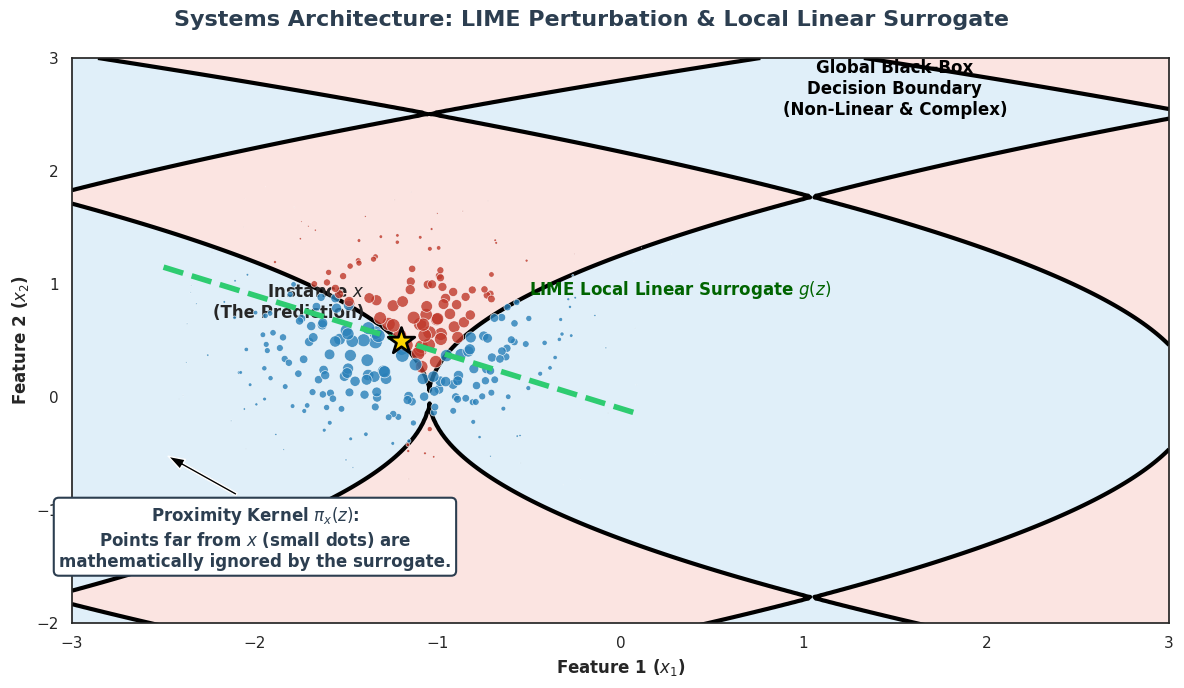

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Systems Architecture: LIME Perturbation & Local Linear Surrogate", fontsize=16, fontweight='bold', color="#2c3e50")

# 1. Simulate a Highly Non-Linear Black Box Decision Boundary
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X_grid, Y_grid = np.meshgrid(x, y)
# Complex non-linear curve: sin(x) + cos(y^2)
Z_boundary = np.sin(X_grid * 1.5) + np.cos(Y_grid**2) 

# Plot the global background (The Black Box's incomprehensible logic)
contour = ax.contourf(X_grid, Y_grid, Z_boundary, levels=0, colors=['#e74c3c', '#3498db'], alpha=0.15)
ax.contour(X_grid, Y_grid, Z_boundary, levels=[0], colors='black', linewidths=3, linestyles='solid')
ax.text(1.5, 2.5, "Global Black-Box\nDecision Boundary\n(Non-Linear & Complex)", ha='center', fontweight='bold', color='black')

# 2. The Instance to Explain (x)
target_x, target_y = -1.2, 0.5
ax.scatter(target_x, target_y, color='gold', s=400, edgecolors='black', linewidth=2, marker='*', zorder=5)
ax.text(target_x - 0.2, target_y + 0.2, "Instance $x$\n(The Prediction)", ha='right', fontweight='bold', fontsize=12)

# 3. Generate Perturbed Dataset (Z) around x
np.random.seed(42)
num_samples = 300
z_x = np.random.normal(target_x, 0.6, num_samples)
z_y = np.random.normal(target_y, 0.6, num_samples)

# Calculate proximity weights pi_x (Exponential distance)
distances = np.sqrt((z_x - target_x)**2 + (z_y - target_y)**2)
weights = np.exp(-(distances**2) / (2 * 0.4**2))

# Color points by the Black Box's prediction
z_predictions = np.sin(z_x * 1.5) + np.cos(z_y**2)
z_colors = ['#c0392b' if val < 0 else '#2980b9' for val in z_predictions]

# Scatter perturbed points, sizing them by their LIME proximity weight
ax.scatter(z_x, z_y, c=z_colors, s=weights * 100, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=3)

# 4. The Local Surrogate Boundary (g)
# Approximate tangent line at (-1.2, 0.5)
slope = -0.5
intercept_y = target_y - slope * target_x
line_x = np.linspace(-2.5, 0.1, 100)
line_y = slope * line_x + intercept_y

ax.plot(line_x, line_y, color='#2ecc71', linewidth=4, linestyle='--', zorder=4)
ax.text(-0.5, 0.9, "LIME Local Linear Surrogate $g(z)$", ha='left', fontweight='bold', color='darkgreen', fontsize=12)

# Formatting
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 3)
ax.set_xlabel("Feature 1 ($x_1$)", fontsize=12, fontweight='bold')
ax.set_ylabel("Feature 2 ($x_2$)", fontsize=12, fontweight='bold')

# Annotate Physics
ax.annotate('Proximity Kernel $\pi_x(z)$:\nPoints far from $x$ (small dots) are\nmathematically ignored by the surrogate.', 
            xy=(-2.5, -0.5), xytext=(-2.0, -1.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2c3e50", lw=1.5))

plt.tight_layout()
plt.show()

*(Insight: The solid black line is the true Neural Network logic—highly curved and mathematically impossible to explain with a simple coefficient. However, if you zoom in close enough to the yellow star (The local neighborhood), the curve flattens out. The large perturbed dots force LIME to learn the green dashed line. In this microscopic region, the green line is a perfect approximation of the black curve, yielding a highly accurate, perfectly interpretable set of linear coefficients.)*

## Real-World Use Case or Analogy

Think of LIME like **Explaining the Physics of the Earth to Someone Standing in a Field**:

* **The Global Black Box (The Spherical Earth):** The Earth is a complex, 3-dimensional, oblate spheroid. If you want to calculate global flight paths or ocean currents, you must use incredibly complex trigonometric equations. You cannot explain these equations with a single "slope."
* **The Global Explainer (Trying to fit a single line):** If you try to fit one straight, linear line to explain the entire Earth, you fail entirely. The model error is massive because a sphere cannot be described by a flat plane globally.
* **LIME / Local Perturbation (The Flat Field):** You stop trying to explain the entire Earth. You focus on a single person standing in a cornfield (The **Instance $x$**).
* **The Proximity Kernel:** You take 5,000 steps around that specific person in a small radius (**Perturbation**). You notice that in a 1-mile radius, the ground altitude barely changes.
* **The Surrogate Model:** You tell the person, *"Right here, the Earth is flat."* (**The Linear Surrogate**).

Is the Earth globally flat? Absolutely not. But in that specific 1-mile neighborhood, treating the Earth as a perfectly flat, linear plane yields a prediction with 99.99% accuracy. LIME provides the simplest possible explanation that remains mathematically faithful to the reality of the user's immediate surroundings.